In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

# Load and Understanding Dataset

In [34]:
# Loading Dataset
df = pd.read_csv("Healthcare_data.csv")

In [35]:
# Display basic information about the dataset
print("Dataset Information:")
print(df.info())

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   PatientID          100 non-null    int64
 1   Gender             100 non-null    str  
 2   Age                100 non-null    int64
 3   Diagnosis          100 non-null    str  
 4   AppointmentDate    100 non-null    str  
 5   MissedAppointment  100 non-null    int64
dtypes: int64(3), str(3)
memory usage: 4.8 KB
None


In [36]:
print("First Few Rows of Data:")
print(df.head())

First Few Rows of Data:
   PatientID  Gender  Age      Diagnosis AppointmentDate  MissedAppointment
0          1    Male   70         Asthma      2023-04-18                  1
1          2  Female   43         Asthma      2023-05-07                  0
2          3  Female   73  Heart Disease      2023-11-12                  0
3          4  Female   49         Asthma      2023-10-15                  0
4          5    Male   65  Heart Disease      2023-03-05                  1


In [37]:
print("Descriptive Statistics:")
print(df.describe())

Descriptive Statistics:
        PatientID         Age  MissedAppointment
count  100.000000  100.000000         100.000000
mean    50.500000   52.370000           0.170000
std     29.011492   17.481682           0.377525
min      1.000000   18.000000           0.000000
25%     25.750000   40.000000           0.000000
50%     50.500000   52.000000           0.000000
75%     75.250000   67.000000           0.000000
max    100.000000   79.000000           1.000000


In [38]:
# Check for missing values
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
PatientID            0
Gender               0
Age                  0
Diagnosis            0
AppointmentDate      0
MissedAppointment    0
dtype: int64


In [39]:
# Display unique values in categorical columns

categorical_columns = df.select_dtypes(include=["object"]).columns
for col in categorical_columns:
    print(f"\nUnique values in {col}:")
    print(df[col].value_counts())


Unique values in Gender:
Gender
Female    52
Male      48
Name: count, dtype: int64

Unique values in Diagnosis:
Diagnosis
Hypertension     29
Heart Disease    27
Diabetes         23
Asthma           21
Name: count, dtype: int64

Unique values in AppointmentDate:
AppointmentDate
2023-04-18    2
2023-12-13    2
2023-11-10    2
2023-11-04    2
2023-03-15    2
             ..
2023-07-25    1
2023-12-17    1
2023-12-16    1
2023-11-06    1
2023-12-05    1
Name: count, Length: 93, dtype: int64


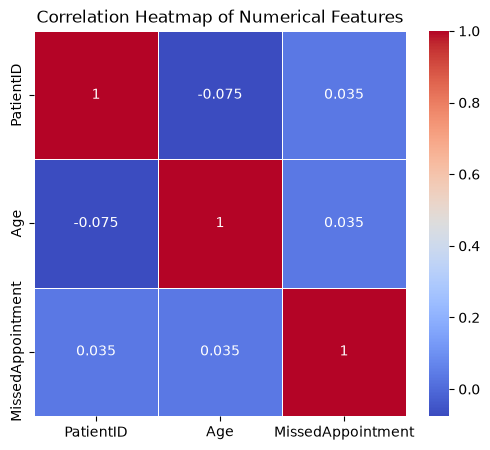

'\nplt.figure(figsize=(10, 8))\nsns.heatmap(data.corr(numeric_only=True), annot=True, cmap="coolwarm")\nplt.savefig("correlation_heatmap.png", dpi=300, bbox_inches="tight")\nplt.show()\n'

In [40]:
# Correlation matrix for numerical columns

# 1st Way
"""
numerical_columns = df.select_dtypes(include= [np.number]).columns
correlation_matrix = df[numerical_columns].corr
"""


# Second Way {Easy}
correlation_matrix = df.corr(numeric_only=True)


# Plot correlation heatmap
plt.figure(figsize=(6,5))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm',
linewidths=0.5)
plt.title('Correlation Heatmap of Numerical Features')
plt.savefig("correlation_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()


"""
plt.figure(figsize=(10, 8))
sns.heatmap(data.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.savefig("correlation_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()
"""

- Correlation analysis helps identify relationships between numerical features. In this dataset, all correlation values are close to zero, indicating that there is no strong linear relationship between Age and MissedAppointment. PatientID is merely an identifier and does not provide meaningful predictive information. Therefore, additional features should be explored to better understand appointment attendance patterns.

# Handling Missing Values

In [41]:


# Check for missing values
missing_values = df.isnull().sum()
print(missing_values[missing_values > 0])


"""
df.isnull().sum() counts the number of missing values in each column. 
By applying the condition > 0, we filter and display only those columns that contain missing values,
making it easier to identify columns that require data cleaning.

"""

Series([], dtype: int64)


'\ndf.isnull().sum() counts the number of missing values in each column. \nBy applying the condition > 0, we filter and display only those columns that contain missing values,\nmaking it easier to identify columns that require data cleaning.\n\n'

In [42]:
"""
# Visualize missing values
plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), yticklabels=False, cbar=False, cmap='viridis')
plt.title('Missing Value Heatmap')
plt.show()
"""

"\n# Visualize missing values\nplt.figure(figsize=(10, 6))\nsns.heatmap(df.isnull(), yticklabels=False, cbar=False, cmap='viridis')\nplt.title('Missing Value Heatmap')\nplt.show()\n"

In [43]:
# # Methods of Handling missing values

# 1. Numeric columns: fill with median
numerical_columns = df.select_dtypes(include = [np.number]).columns

for cols in numerical_columns:
    df[col].fillna(df[cols].median(), inplace=True)

In [44]:
# 2. Categorical columns: fill with mode
categorical_columns = df.select_dtypes(include = [object]).columns

for col in categorical_columns:
    df[col].fillna(df[col].mode()[0], inplace=True)

"""mode()[0] is used to selct first mode because it resurn series od mode"""

'mode()[0] is used to selct first mode because it resurn series od mode'

In [45]:
# 3. Drop rows with any remaining missing values
df.dropna(inplace=True)

In [46]:
# 4. Drop columns with excessive missing values (threshold: 50%)
df = df.dropna(thresh=len(df) * 0.5, axis=1)

- dropna(thresh=n, axis=1) removes columns that do not have at least n non-missing values. In this example, columns with more than 50% missing data are removed because they may not provide reliable information for analysis or model training.

In [47]:
print("Data after handling missing values:")
print(df.info())

Data after handling missing values:
<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   PatientID          100 non-null    int64
 1   Gender             100 non-null    str  
 2   Age                100 non-null    int64
 3   Diagnosis          100 non-null    str  
 4   AppointmentDate    100 non-null    str  
 5   MissedAppointment  100 non-null    int64
dtypes: int64(3), str(3)
memory usage: 4.8 KB
None


In [48]:
# Check for any remaining missing values
remaining_missing = df.isnull().sum().sum()
print(f"Remaining missing values: {remaining_missing}")

Remaining missing values: 0


In [49]:
# Display summary statistics after handling missing values
print("Summary Statistics After Handling Missing Values:")
print(df.describe())

Summary Statistics After Handling Missing Values:
        PatientID         Age  MissedAppointment
count  100.000000  100.000000         100.000000
mean    50.500000   52.370000           0.170000
std     29.011492   17.481682           0.377525
min      1.000000   18.000000           0.000000
25%     25.750000   40.000000           0.000000
50%     50.500000   52.000000           0.000000
75%     75.250000   67.000000           0.000000
max    100.000000   79.000000           1.000000


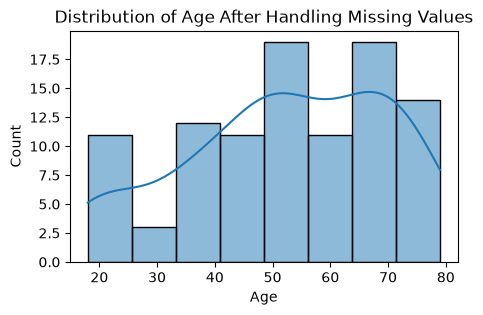

In [50]:
# Visualize the distribution of a key numeric variable (e.g., 'Age')
plt.figure(figsize=(5, 3))
sns.histplot(df['Age'], kde=True)
plt.title('Distribution of Age After Handling Missing Values')
plt.savefig("Distribution-Of-Age", dpi=300, bbox_inches="tight" )
plt.show()

# Handling Categorical Variables

In [51]:
# Identify categorical variables
categorical_vars = df.select_dtypes(include=['object']).columns
print("Categorical variables:", categorical_vars)


Categorical variables: Index(['Gender', 'Diagnosis', 'AppointmentDate'], dtype='str')


In [52]:
# Display unique values in categorical variables
for col in categorical_vars:
    print(f"Unique values in {col}:")
    print(df[col].value_counts())

Unique values in Gender:
Gender
Female    52
Male      48
Name: count, dtype: int64
Unique values in Diagnosis:
Diagnosis
Hypertension     29
Heart Disease    27
Diabetes         23
Asthma           21
Name: count, dtype: int64
Unique values in AppointmentDate:
AppointmentDate
2023-04-18    2
2023-12-13    2
2023-11-10    2
2023-11-04    2
2023-03-15    2
             ..
2023-07-25    1
2023-12-17    1
2023-12-16    1
2023-11-06    1
2023-12-05    1
Name: count, Length: 93, dtype: int64


In [53]:
# Convert categorical variables to dummy variables
df_encoded = pd.get_dummies(df, columns=categorical_vars,drop_first=True)

print("Data after encoding categorical variables:")
print(df_encoded.head())

Data after encoding categorical variables:
   PatientID  Age  MissedAppointment  Gender_Male  Diagnosis_Diabetes  \
0          1   70                  1         True               False   
1          2   43                  0        False               False   
2          3   73                  0        False               False   
3          4   49                  0        False               False   
4          5   65                  1         True               False   

   Diagnosis_Heart Disease  Diagnosis_Hypertension  \
0                    False                   False   
1                    False                   False   
2                     True                   False   
3                    False                   False   
4                     True                   False   

   AppointmentDate_2023-01-16  AppointmentDate_2023-01-18  \
0                       False                       False   
1                       False                       False   
2         

In [54]:
# Compare shapes before and after encoding
print(f"Shape before encoding: {df.shape}")
print(f"Shape after encoding: {df_encoded.shape}")

Shape before encoding: (100, 6)
Shape after encoding: (100, 99)


In [55]:
# Check for multicollinearity in encoded variables
correlation_matrix = df_encoded.corr()
high_corr = np.abs(correlation_matrix) > 0.8
print("Highly correlated features:")
print(high_corr[high_corr].index[high_corr.any()].tolist())

Highly correlated features:
['PatientID', 'Age', 'MissedAppointment', 'Gender_Male', 'Diagnosis_Diabetes', 'Diagnosis_Heart Disease', 'Diagnosis_Hypertension', 'AppointmentDate_2023-01-16', 'AppointmentDate_2023-01-18', 'AppointmentDate_2023-01-23', 'AppointmentDate_2023-01-24', 'AppointmentDate_2023-01-29', 'AppointmentDate_2023-01-31', 'AppointmentDate_2023-02-03', 'AppointmentDate_2023-02-06', 'AppointmentDate_2023-02-07', 'AppointmentDate_2023-02-23', 'AppointmentDate_2023-02-27', 'AppointmentDate_2023-03-05', 'AppointmentDate_2023-03-06', 'AppointmentDate_2023-03-08', 'AppointmentDate_2023-03-09', 'AppointmentDate_2023-03-11', 'AppointmentDate_2023-03-15', 'AppointmentDate_2023-03-23', 'AppointmentDate_2023-03-24', 'AppointmentDate_2023-03-25', 'AppointmentDate_2023-03-30', 'AppointmentDate_2023-03-31', 'AppointmentDate_2023-04-05', 'AppointmentDate_2023-04-08', 'AppointmentDate_2023-04-18', 'AppointmentDate_2023-04-20', 'AppointmentDate_2023-04-25', 'AppointmentDate_2023-04-30', 

> Why Check Multicollinearity?

- Highly correlated features can:
   - Confuse Linear Regression models
   - Make coefficients unstable
   - Increase variance
   - Reduce model interpretability
   

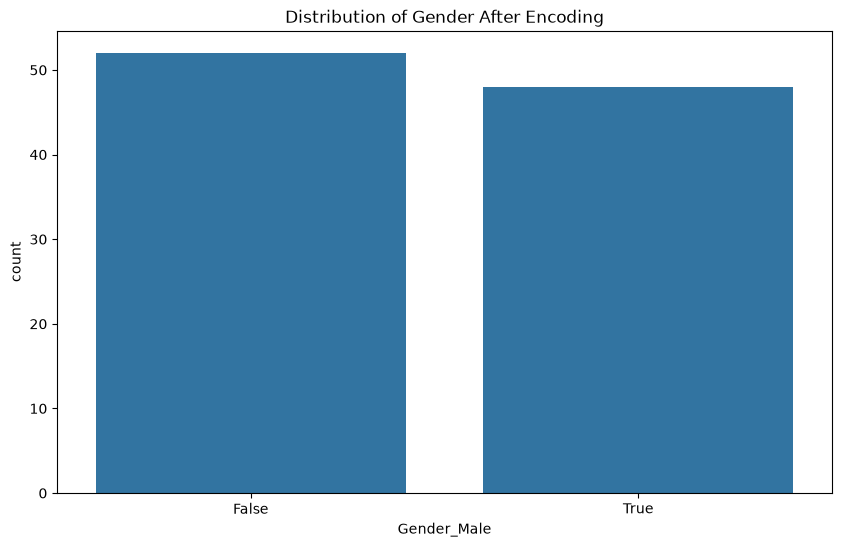

In [56]:
# Visualize the distribution of a newly encoded variable
plt.figure(figsize=(10, 6))
sns.countplot(x='Gender_Male', data=df_encoded)
plt.title('Distribution of Gender After Encoding')
plt.savefig("Distribution-Of-Gender-After-Encoding", dpi=300, bbox_inches="tight")
plt.show()

# EDA

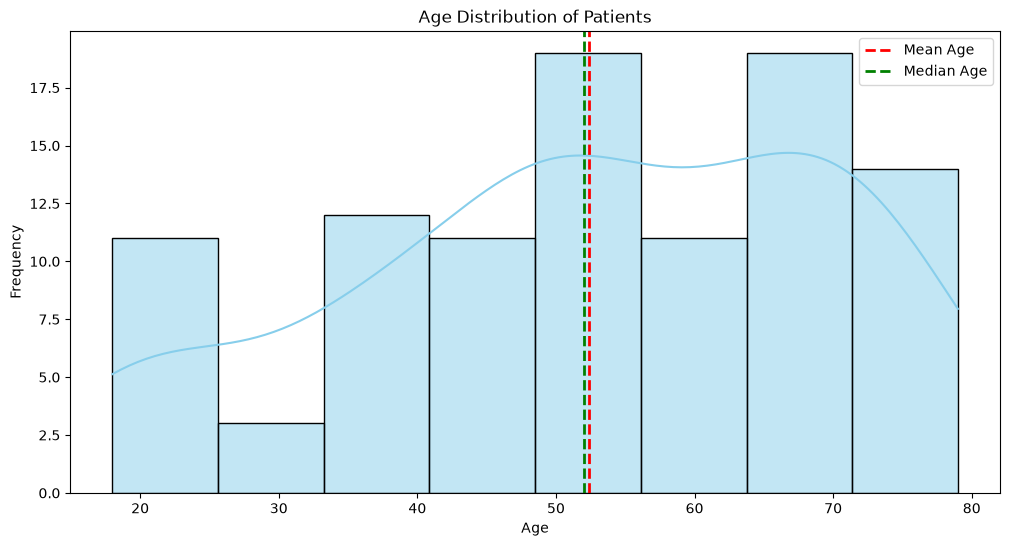

In [57]:
# Plot Age Distribution

# Import required libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Create a figure with width=12 inches and height=6 inches
plt.figure(figsize=(12, 6))

# Plot histogram of the Age column
# kde=True adds a smooth density curve
# color sets the bar color
# edgecolor adds borders around bars
sns.histplot(
    data=df,
    x='Age',
    kde=True,
    color='skyblue',
    edgecolor='black'
)

# Set x-axis label
plt.xlabel('Age')

# Set y-axis label
plt.ylabel('Frequency')

# Add title to the plot
plt.title('Age Distribution of Patients')

# Draw a vertical dashed red line at the mean age
# Mean = average age of all patients
plt.axvline(
    x=df['Age'].mean(),
    color='red',
    linestyle='dashed',
    linewidth=2,
    label='Mean Age'
)

# Draw a vertical dashed green line at the median age
# Median = middle value when ages are sorted
plt.axvline(
    x=df['Age'].median(),
    color='green',
    linestyle='dashed',
    linewidth=2,
    label='Median Age'
)

# Display legend showing Mean Age and Median Age
plt.legend()
plt.savefig("Age-Distribution-Of-Patients(With-Mean-Median-Line)",  dpi=300, bbox_inches="tight")
# Display the final plot
plt.show()

In [58]:
"""
In EDA (Exploratory Data Analysis)

We plot mean and median to:

- Understand the center of the data.
- Detect skewness.
- Identify possible outliers.
- Decide whether mean or median is a better summary statistic.
- Better understand the feature before modeling.



Mean ≈ Median	Normal/Symmetric distribution
Mean > Median	Right-skewed distribution
Mean < Median	Left-skewed distribution
"""

'\nIn EDA (Exploratory Data Analysis)\n\nWe plot mean and median to:\n\n- Understand the center of the data.\n- Detect skewness.\n- Identify possible outliers.\n- Decide whether mean or median is a better summary statistic.\n- Better understand the feature before modeling.\n\n\n\nMean ≈ Median\tNormal/Symmetric distribution\nMean > Median\tRight-skewed distribution\nMean < Median\tLeft-skewed distribution\n'

In [59]:
# Age statistics
age_stats = df['Age'].describe()
print("Age Statistics:")
print(age_stats)

Age Statistics:
count    100.000000
mean      52.370000
std       17.481682
min       18.000000
25%       40.000000
50%       52.000000
75%       67.000000
max       79.000000
Name: Age, dtype: float64


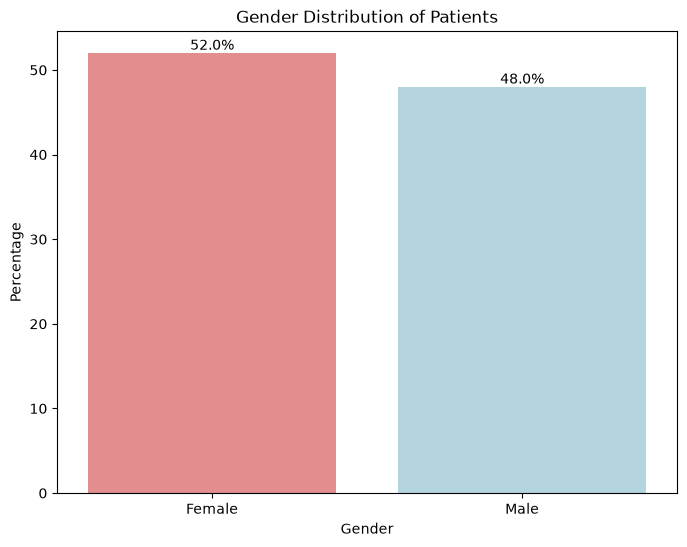

In [60]:
# Create figure of size 8x6 inches
plt.figure(figsize=(8, 6))

# Count number of males and females
gender_counts = df['Gender'].value_counts()

# Convert counts to percentages
gender_percentages = gender_counts / len(df) * 100

# Create bar chart
sns.barplot(
    x=gender_counts.index,      # Gender categories
    y=gender_percentages,       # Percentage values
    palette=['lightcoral', 'lightblue']
)

# X-axis label
plt.xlabel('Gender')

# Y-axis label
plt.ylabel('Percentage')

# Chart title
plt.title('Gender Distribution of Patients')

# Add percentage labels above bars
for i, v in enumerate(gender_percentages):
    plt.text(
        i,                      # x-position
        v,                      # y-position
        f'{v:.1f}%',            # formatted text
        ha='center',            # horizontal alignment
        va='bottom'             # vertical alignment
    )

plt.savefig("Gender-Distribution-of-Patients", dpi=300, bbox_inches='tight')

# Display chart
plt.show()

In [61]:
# Print gender statistics
print("Gender Distribution:")
print(gender_counts)
print(f"Gender Percentages: {gender_percentages}")

Gender Distribution:
Gender
Female    52
Male      48
Name: count, dtype: int64
Gender Percentages: Gender
Female    52.0
Male      48.0
Name: count, dtype: float64


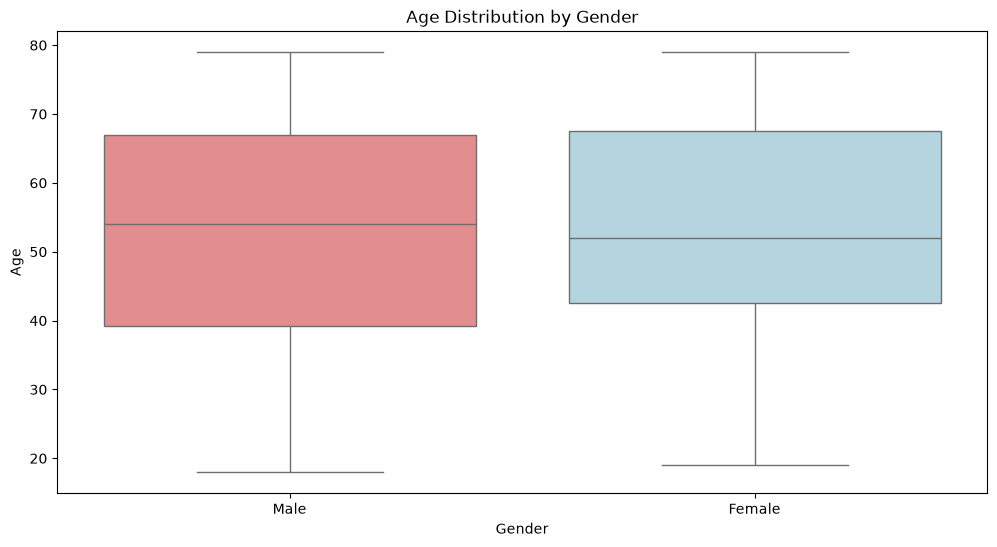

In [62]:
# Age distribution by gender
plt.figure(figsize=(12, 6))
sns.boxplot(x='Gender', y='Age', data=df, palette=['lightcoral', 'lightblue'])
plt.title('Age Distribution by Gender')
plt.savefig("Gender-Distribution-By-Gender", dpi=300, bbox_inches='tight')
plt.show()

In [63]:
# Age statistics by gender
age_by_gender = df.groupby('Gender')['Age'].describe()
print("Age Statistics by Gender:")
print(age_by_gender)

Age Statistics by Gender:
        count       mean        std   min    25%   50%   75%   max
Gender                                                            
Female   52.0  52.365385  17.864445  19.0  42.50  52.0  67.5  79.0
Male     48.0  52.375000  17.246184  18.0  39.25  54.0  67.0  79.0


In [66]:
# Correlation between age and a numeric health indicator (e.g., BMI)
if 'BMI' in df.columns:
    plt.figure(figsize=(10, 6))
    sns.scatterplot(x='Age', y='BMI', data=df, hue='Gender', palette=
    ['lightcoral', 'lightblue'])
    plt.title('Age vs BMI by Gender')
    plt.show()
    correlation = df['Age'].corr(df['BMI'])
    print(f"Correlation between Age and BMI: {correlation:.2f}")

In [69]:
# Diagnosis distribution
diagnosis_counts = df.filter(like='Diagnosis_').sum().sort_values(ascending=False)

if not diagnosis_counts.empty:
    # Create bar plot
    plt.figure(figsize=(12, 8))
    ax = diagnosis_counts.plot(kind='bar', color='teal', edgecolor='black')
    plt.xlabel('Diagnosis')
    plt.ylabel('Count')
    plt.title('Distribution of Diagnoses')
    plt.xticks(rotation=45, ha='right')

    # Add value labels on top of each bar
    for i, v in enumerate(diagnosis_counts):
        ax.text(i, v, str(v), ha='center', va='bottom')

    # Add a horizontal line for the mean
    mean_count = diagnosis_counts.mean()
    plt.axhline(y=mean_count, color='red', linestyle='--', label=f'Mean({mean_count:.2f})')

    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print("No diagnosis data available to plot.")


No diagnosis data available to plot.


In [70]:
print(df.filter(like='Diagnosis_').head())
print(diagnosis_counts)

Empty DataFrame
Columns: []
Index: [0, 1, 2, 3, 4]
Series([], dtype: float64)
